In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(f"PyTorch Version: {torch.__version__}")
# Check if Apple Silicon GPU (MPS) is available
if torch.backends.mps.is_available():
    print("Apple M-Series GPU (MPS) is AVAILABLE. The model will fly!")
    device = torch.device("mps")
else:
    print("MPS not found. Falling back to CPU.")
    device = torch.device("cpu")

PyTorch Version: 2.11.0
Apple M-Series GPU (MPS) is AVAILABLE. The model will fly!


In [2]:
class RFConstellationDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            img_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        # Create a dictionary mapping the 16 modulation names to integer IDs (0 to 15)
        # Neural networks can only predict numbers, not strings!
        self.unique_modulations = sorted(self.annotations['modulation'].unique())
        self.mod_to_idx = {mod: idx for idx, mod in enumerate(self.unique_modulations)}
        self.idx_to_mod = {idx: mod for mod, idx in self.mod_to_idx.items()}

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # 1. Get the image file name from the CSV
        img_name = os.path.join(self.img_dir, self.annotations.iloc[index, 0])
        
        # 2. Open the image and convert it to standard RGB
        # (Even though our images are cyan/black, PyTorch expects 3 color channels)
        image = Image.open(img_name).convert('RGB')
        
        # 3. Get the string label (e.g., "16-QAM") and convert it to an integer (e.g., 7)
        label_str = self.annotations.iloc[index, 1]
        y_label = torch.tensor(self.mod_to_idx[label_str], dtype=torch.long)
        
        # 4. Apply any image transformations (like resizing or turning into a Tensor)
        if self.transform:
            image = self.transform(image)
            
        return image, y_label

print("Dataset class successfully defined!")

Dataset class successfully defined!


In [5]:
# --- 1. Define Transformations ---
# CNNs (like ResNet) expect images to be Tensors and normalized to specific mathematical ranges
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Guarantee size
    transforms.ToTensor(),         # Convert from pixels (0-255) to float tensors (0.0-1.0)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ResNet normalization
                         std=[0.229, 0.224, 0.225])
])

# --- 2. Load the Full CSV to Split it ---
# Assuming this notebook is sitting right next to dataset_labels.csv
full_df = pd.read_csv('dataset_labels.csv')

# Split 80% for Training, 20% for Validation
# 'stratify' ensures both sets get an equal mix of all 16 modulations
train_df, val_df = train_test_split(full_df, test_size=0.20, random_state=42, stratify=full_df['modulation'])

# Save the splits to new CSVs so the Dataset class can read them
train_df.to_csv('train_labels.csv', index=False)
val_df.to_csv('val_labels.csv', index=False)

print(f"Total Images: {len(full_df)}")
print(f"Training Images: {len(train_df)}")
print(f"Validation Images: {len(val_df)}")

# --- 3. Instantiate the Datasets ---
# The img_dir is '.' because the images are in the same folder as this notebook
train_dataset = RFConstellationDataset(csv_file='train_labels.csv', img_dir='.', transform=data_transforms)
val_dataset = RFConstellationDataset(csv_file='val_labels.csv', img_dir='.', transform=data_transforms)

# --- 4. Create the DataLoaders ---
# Setting num_workers=0 forces PyTorch to load data on the main thread, 
# bypassing the macOS Jupyter multiprocessing bug!
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, num_workers=0)

print("DataLoaders are fully charged and ready!")

Total Images: 3072
Training Images: 2457
Validation Images: 615
DataLoaders are fully charged and ready!


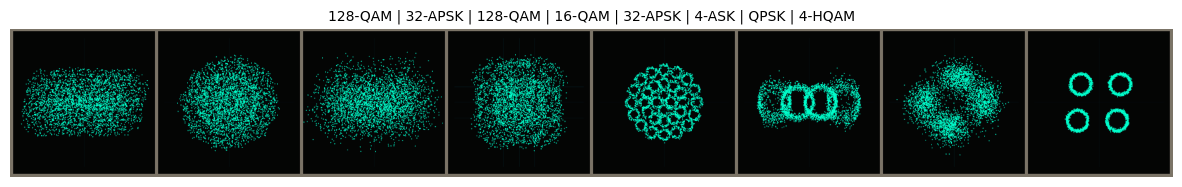

In [6]:
import numpy as np
import torchvision

# 1. Grab a single batch of data from the training loader
# iter() turns the loader into an iterator, and next() grabs the first batch.
# Since we set batch_size=32, 'images' will contain 32 images, and 'labels' will contain 32 answers.
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 2. Create a helper function to "un-normalize" the tensors back into viewable pixels
def imshow(inp, title=None):
    """Imshow for Tensor."""
    # inp is a mathematical tensor. We need to convert it to a NumPy array for matplotlib.
    inp = inp.numpy().transpose((1, 2, 0))
    
    # We normalized the images earlier using these exact mean and std values. 
    # To view them, we have to reverse that math: image = (image * std) + mean
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    
    # Clip the values to make sure they stay between 0.0 and 1.0 (valid pixel colors)
    inp = np.clip(inp, 0, 1)
    
    # Draw the image
    plt.figure(figsize=(15, 6))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')
    plt.show()

# 3. Use torchvision.utils.make_grid to stitch the first 8 images of the batch together
# This creates a nice horizontal strip of images so we can see a variety of modulations.
out = torchvision.utils.make_grid(images[:8], padding=5)

# 4. Map the integer labels (e.g., 7) back to their string names (e.g., "16-QAM")
# We use the idx_to_mod dictionary we created in the Dataset class.
title_str = " | ".join([train_dataset.idx_to_mod[x.item()] for x in labels[:8]])

# 5. Display the grid!
imshow(out, title=title_str)

In [7]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load a pre-trained ResNet-18 model
# 'weights=models.ResNet18_Weights.DEFAULT' means we start with a brain that already knows how to see edges, shapes, and patterns.
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Modify the final layer (the "classifier")
# ResNet-18 was originally trained on ImageNet (1000 classes). 
# We need to replace the final layer to output exactly 16 classes (our modulations).
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 16)

# 3. Move the model to your M1 Max GPU
model = model.to(device)

# 4. Define the Loss Function and Optimizer
# CrossEntropyLoss is the standard mathematical tool for classification tasks.
criterion = nn.CrossEntropyLoss()

# Adam is a highly efficient optimization algorithm that adjusts the model's weights to minimize the loss.
# lr=0.001 is a standard starting learning rate.
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ResNet-18 Model is loaded, modified, and moved to the GPU!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/andreasodontopoulos/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 93.0MB/s]

ResNet-18 Model is loaded, modified, and moved to the GPU!


In [9]:
import time
import copy

num_epochs = 10
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []

print("Starting Training Loop on M1 Max GPU (MPS)...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()   
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1) 
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()   
                    optimizer.step()  

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.float() / dataset_size

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_loss_history.append(epoch_loss)
            train_acc_history.append(epoch_acc.item())
        else:
            val_loss_history.append(epoch_loss)
            val_acc_history.append(epoch_acc.item())

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print("🌟 New best model saved!")
    print()

time_elapsed = time.time() - start_time
print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best Validation Accuracy: {best_acc:4f}')

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'resnet18_rf_model.pth')
print("Model saved to 'resnet18_rf_model.pth'")

Starting Training Loop on M1 Max GPU (MPS)...
Epoch 1/10
----------
Train Loss: 0.5115 Acc: 0.7733
Val Loss: 15.0352 Acc: 0.0618
🌟 New best model saved!

Epoch 2/10
----------
Train Loss: 0.4449 Acc: 0.8091
Val Loss: 20.9145 Acc: 0.0618

Epoch 3/10
----------
Train Loss: 0.3841 Acc: 0.8323
Val Loss: 3.0423 Acc: 0.3366
🌟 New best model saved!

Epoch 4/10
----------
Train Loss: 0.2965 Acc: 0.8657
Val Loss: 0.9981 Acc: 0.6894
🌟 New best model saved!

Epoch 5/10
----------
Train Loss: 0.2869 Acc: 0.8783
Val Loss: 7.5465 Acc: 0.2098

Epoch 6/10
----------
Train Loss: 0.2439 Acc: 0.8987
Val Loss: 0.8300 Acc: 0.7577
🌟 New best model saved!

Epoch 7/10
----------
Train Loss: 0.2160 Acc: 0.9133
Val Loss: 1.9622 Acc: 0.6667

Epoch 8/10
----------
Train Loss: 0.1660 Acc: 0.9345
Val Loss: 0.6965 Acc: 0.8000
🌟 New best model saved!

Epoch 9/10
----------
Train Loss: 0.1006 Acc: 0.9670
Val Loss: 0.7463 Acc: 0.7886

Epoch 10/10
----------
Train Loss: 0.1323 Acc: 0.9479
Val Loss: 2.0960 Acc: 0.5431

T

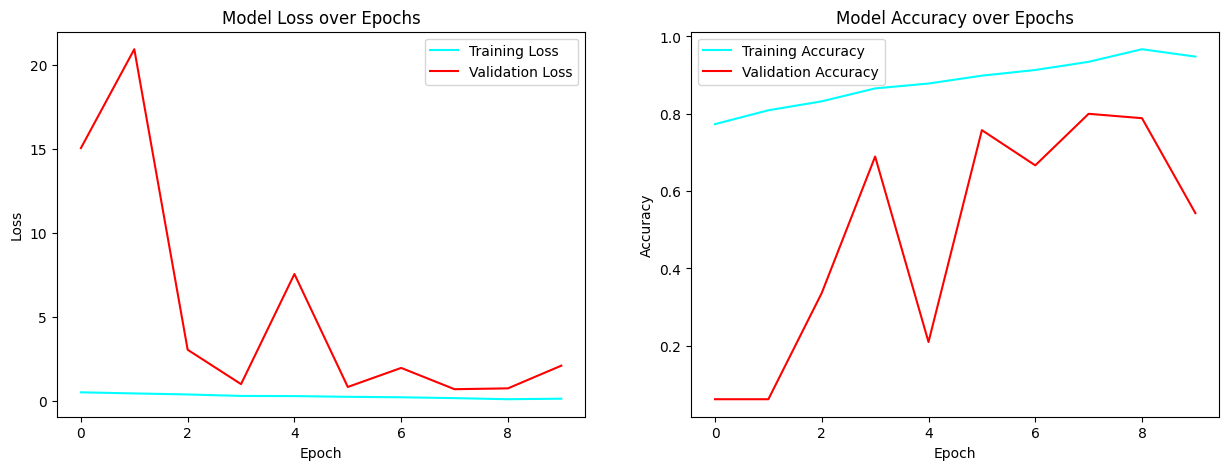

Generating Confusion Matrix on Validation Data...


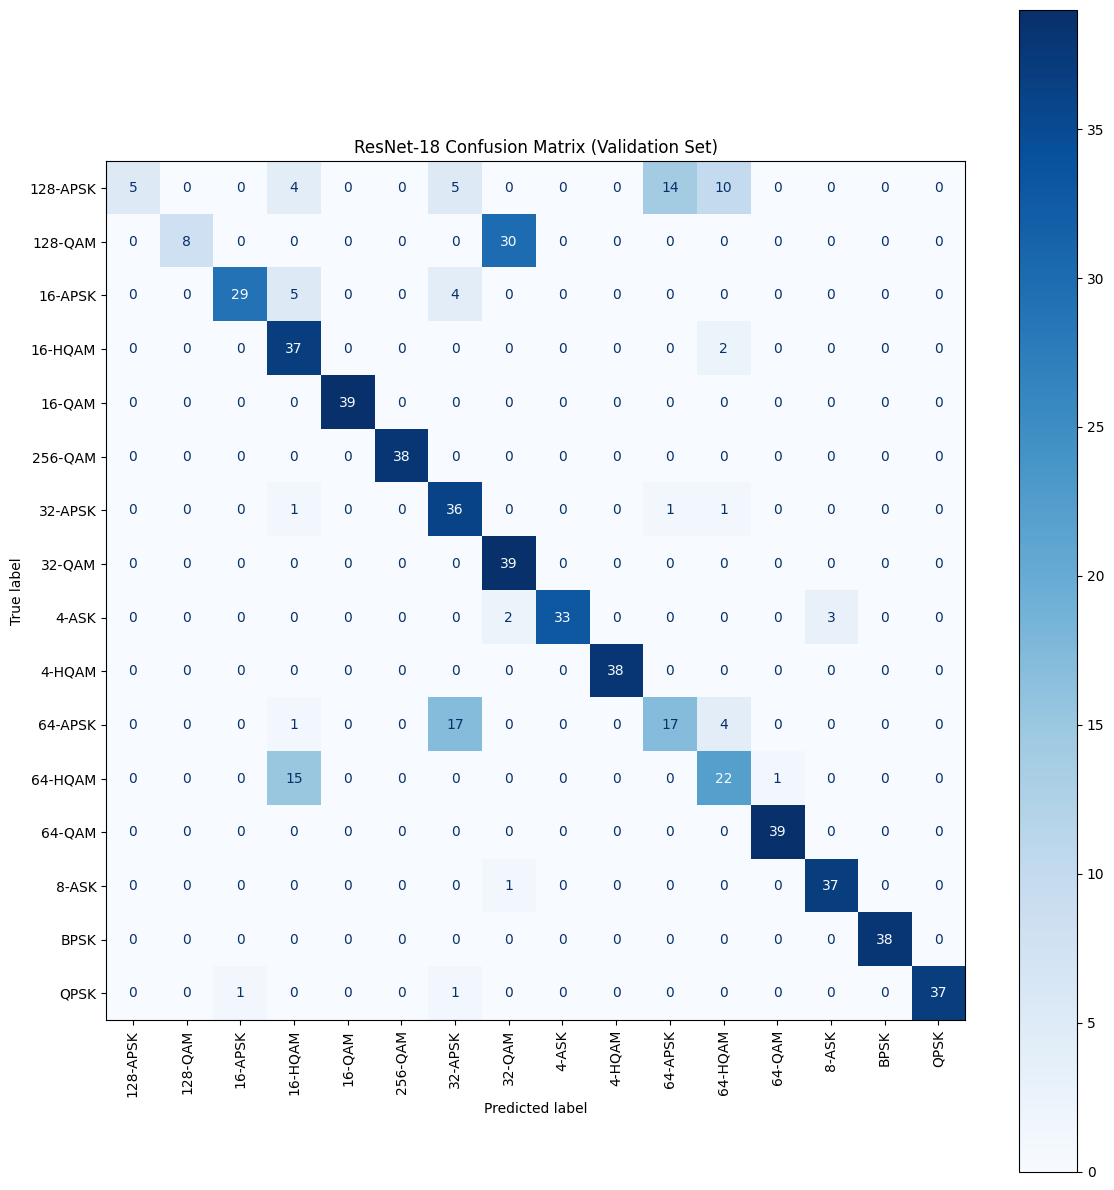

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Plot the Learning Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Plot
ax1.plot(train_loss_history, label='Training Loss', color='cyan')
ax1.plot(val_loss_history, label='Validation Loss', color='red')
ax1.set_title('Model Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy Plot
ax2.plot(train_acc_history, label='Training Accuracy', color='cyan')
ax2.plot(val_acc_history, label='Validation Accuracy', color='red')
ax2.set_title('Model Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

# --- 2. Generate the Confusion Matrix ---
print("Generating Confusion Matrix on Validation Data...")
model.eval() # Ensure model is in testing mode
all_preds = []
all_labels = []

# Pass all validation images through the best saved model
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate and Draw the Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.unique_modulations)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.title('ResNet-18 Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

Saved learning_curves.pdf
Saved confusion_matrix.pdf

--- ACADEMIC CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    128-APSK       1.00      0.13      0.23        38
     128-QAM       1.00      0.21      0.35        38
     16-APSK       0.97      0.76      0.85        38
     16-HQAM       0.59      0.95      0.73        39
      16-QAM       1.00      1.00      1.00        39
     256-QAM       1.00      1.00      1.00        38
     32-APSK       0.57      0.92      0.71        39
      32-QAM       0.54      1.00      0.70        39
       4-ASK       1.00      0.87      0.93        38
      4-HQAM       1.00      1.00      1.00        38
     64-APSK       0.53      0.44      0.48        39
     64-HQAM       0.56      0.58      0.57        38
      64-QAM       0.97      1.00      0.99        39
       8-ASK       0.93      0.97      0.95        38
        BPSK       1.00      1.00      1.00        38
        QPSK       1.00      0.95      0.9

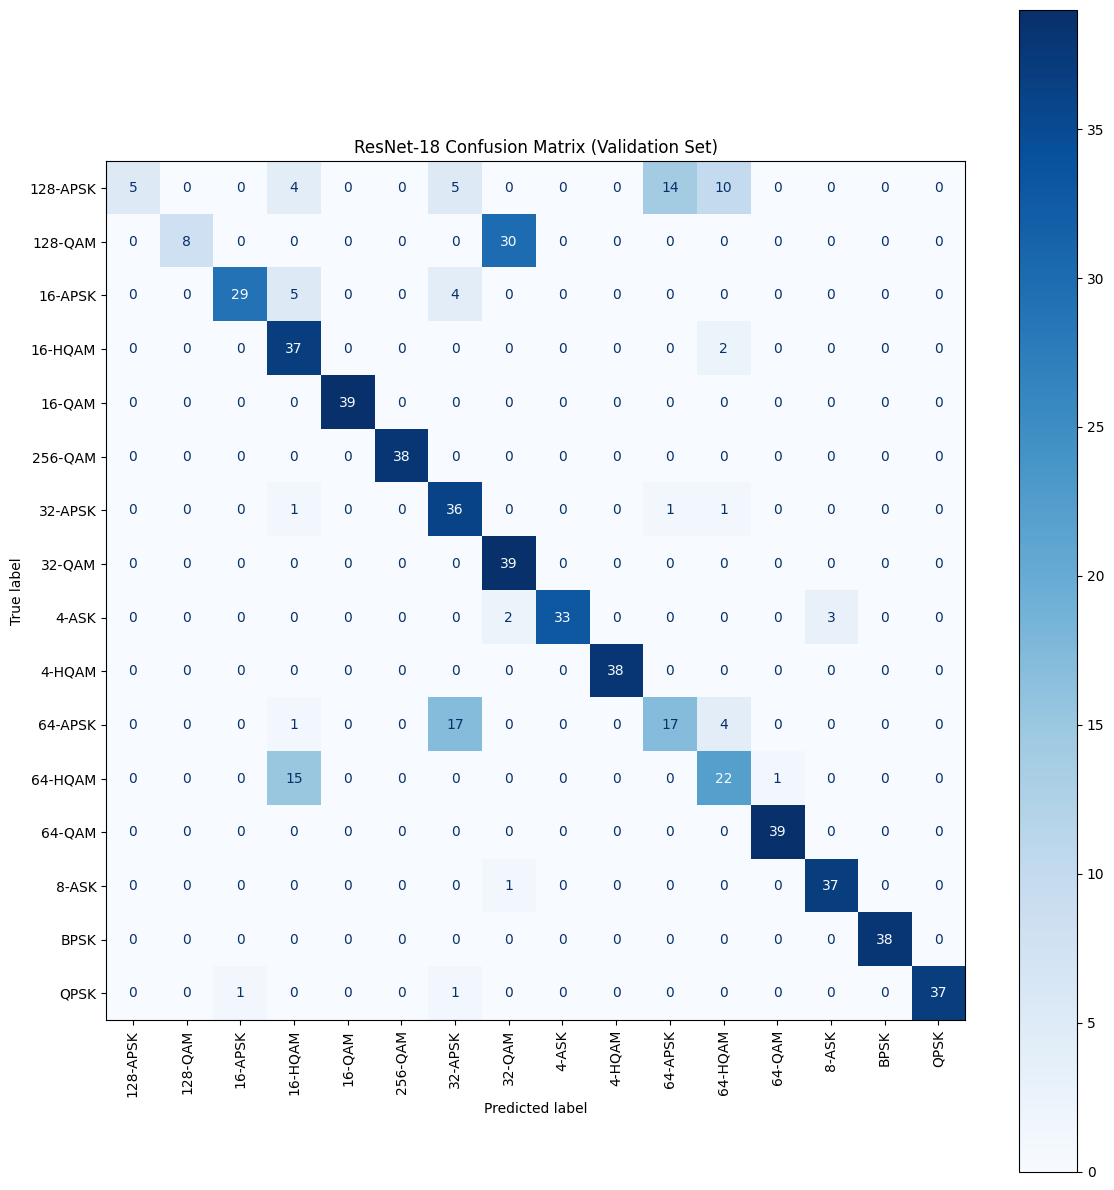

: 

In [ ]:
from sklearn.metrics import classification_report
import os

# 1. Save the Loss/Accuracy Curves
fig.savefig('learning_curves.pdf', format='pdf', bbox_inches='tight')
print("Saved learning_curves.pdf")

# 2. Save the Confusion Matrix
fig_cm, ax_cm = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax_cm, cmap='Blues', xticks_rotation='vertical')
plt.title('ResNet-18 Confusion Matrix (Validation Set)')
plt.tight_layout()
fig_cm.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')
print("Saved confusion_matrix.pdf")

# 3. Generate and Save the Academic Classification Report
report = classification_report(all_labels, all_preds, target_names=train_dataset.unique_modulations)
print("\n--- ACADEMIC CLASSIFICATION REPORT ---")
print(report)

# Save report to a text file for your thesis appendix
with open("classification_metrics.txt", "w") as f:
    f.write(report)